In [89]:
%load_ext autoreload
%autoreload 2
from typing import Literal

from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from evaluate import PlottingWrapper

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Helpers

In [90]:
TEXT_WIDTH = 418.25372 / 72.27  # 418... is the width in dots of the latex paper; latex uses 72.27 dots per inch

FULL_WIDTH = TEXT_WIDTH     # physical paper width
MEDIUM_WIDTH = FULL_WIDTH * 0.8
HALF_WIDTH = TEXT_WIDTH * 0.5
PLOT_HEIGHT = 4

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.0,
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,

        "axes.linewidth": 1.4,
        "axes.edgecolor": "0.4",

        "xtick.color": "0.4",
        "ytick.color": "0.4",
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.major.size": 4,
        "ytick.major.size": 4,

        "axes.labelweight": "medium",
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "figure.titleweight": "bold",

        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 10,
        "legend.title_fontsize": 11,
        "figure.titlesize": 14
    }
)

dataset_names = {
    "mmlu-pro": "MMLU-Pro",
    "alpaca": "Alpaca",
    "MATH": "MATH",
    "ifbench": "IFBench",
    "flores": "FLORES+"
}

colors = {
    "Positive": "#61975A",
    "Neutral": "#DDA75D",
    "Negative": "#D45053",
}

In [91]:
plotting_wrapper = PlottingWrapper()

plot_path = Path("plots/results")

In [92]:
dfs = []
for file in Path("data/evaluation/").iterdir():
    dataset_name = file.stem
    if file.suffix != ".csv":
        continue
    raw_df = pd.read_csv(file, index_col=0)
    raw_df = raw_df.rename(columns={"iso_639_3": "category", "subject": "category"})

    raw_df.insert(0, "dataset", dataset_name)
    dfs.append(raw_df)
df = pd.concat(dfs, ignore_index=True)
df["dataset"] = df["dataset"].replace(dataset_names)

In [93]:
df = df.rename(columns={"score": "Score", "dataset": "Dataset"})

df["Persona"] = df["persona"].str.replace("_teacher", "")
df["Persona"] = df["Persona"].str.replace("_", "-", regex=False).str.title()
df["Persona"] = df["Persona"].str.replace("Short", "S")
df["Persona"] = df["Persona"].str.replace("Medium", "M")
df["Persona"] = df["Persona"].str.replace("Long", "L")
df["Persona"] = df["Persona"].str.replace("Intermediate", "Interm.")

In [94]:
winrate_mask = df["Dataset"].isin(["Alpaca", "FLORES+"])
winrate_df = df[winrate_mask].copy()

# before length_base_copy but after persona changing
df = df[~(winrate_mask & (df["Score"] == 1))].copy()
winrate_mask = df["Dataset"].isin(["Alpaca", "FLORES+"])
df.loc[winrate_mask & (df["Score"] == 2), "Score"] = 1

In [95]:
length_base_df = df.copy()

In [96]:
_PERSONA_ORDERING = [
    "Base",
    "Static-S", "Static-M", "Static-L",
    "Dynamic-S", "Dynamic-M", "Dynamic-L",
    "Beginner", "Interm.", "Expert",
]
_order_map = {v: i for i, v in enumerate(_PERSONA_ORDERING)}

In [97]:
def compute_gains(
    data: pd.Series,
    baseline_col: str = "Helpful"
) -> pd.Series:
    """Computes the performance gain against some baseline.

    Args:
        data (pd.Series): Data used to calculate the performance gain on.
        baseline_col (str): Baseline column.

    Returns:
        pd.Series: Series with performance gains.
    """
    data = data.copy()
    for persona_ in _PERSONA_ORDERING:
        data[persona_] -= data[baseline_col]
    data = data.drop(index=baseline_col)
    return data[_PERSONA_ORDERING]

In [98]:
tests_baseline_df = pd.read_csv("data/evaluation/tests/results_baseline.csv")
tests_baseline_model_df = pd.read_csv("data/evaluation/tests/results_baseline_model.csv")

tests_length_df = pd.read_csv("data/evaluation/tests/results_length.csv")
tests_length_model_df = pd.read_csv("data/evaluation/tests/results_length_model.csv")
tests_length_model_lr_df = pd.read_csv("data/evaluation/tests/results_length_model_lr.csv")

tests_teacher_df = pd.read_csv("data/evaluation/tests/results_teacher.csv")
tests_teacher_model_df = pd.read_csv("data/evaluation/tests/results_teacher_model.csv")
tests_teacher_model_lr_df = pd.read_csv("data/evaluation/tests/results_teacher_model_lr.csv")

tests_dynamic_df = pd.read_csv("data/evaluation/tests/results_static_vs_dynamic.csv")
tests_dynamic_model_df = pd.read_csv("data/evaluation/tests/results_static_vs_dynamic_model.csv")
tests_dynamic_model_lr_df = pd.read_csv("data/evaluation/tests/results_static_vs_dynamic_model_lr.csv")

def print_sig(
    sig_df: pd.DataFrame,
    group_col: str
):
    """Prints p-values and coefficients of significant terms.

    Args:
        sig_df (pd.DataFrame): Dataframe with significance results.
        group_col (str): Column used to group the results. Results are always grouped by dataset.
    """
    for dataset_id, dataset_subset in sig_df.groupby("dataset"):
        print(f" === {dataset_id} ===")
        for d_name, sig_group_df in dataset_subset.groupby(group_col):
            print(f"    === {d_name}")
            sig = sig_group_df[sig_group_df["pvalue"] < 0.05]
            for row in sig.itertuples():
                if row.term == "Intercept" or "llama" in row.term or "wen" in row.term or "gpt" in row.term or "gemma" in row.term\
                        or "1/2" in row.term or "no" in row.term or "0" in row.term or "1" in row.term or "2" in row.term:
                    continue
                print(f"    Persona {row.term:<20} p-val {row.pvalue:.3f} coef {row.coef:.3f}")
                if hasattr(row, "mode"):
                    print(row.mode)

# 1. Persona vs. Baseline

## Aggregate Performance Across all Datasets (except flores) and Models

In [99]:
aggregate_df = df.copy()
dataset_df = aggregate_df[~aggregate_df["Dataset"].isin(["FLORES+", "Alpaca"])]
aggregate_df = dataset_df.groupby(["Persona"])["Score"].mean()
aggregate_df = compute_gains(aggregate_df)

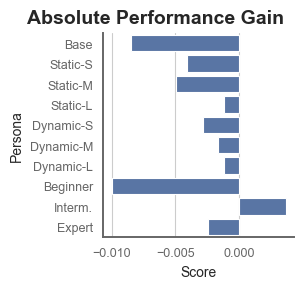

In [126]:
fig, ax = plt.subplots(figsize=(HALF_WIDTH, 3.0))

sns.barplot(aggregate_df, ax=ax, width=0.8, orient="h")

fig.suptitle("Absolute Performance Gain")

fig.subplots_adjust(
    left=0.32,
    right=0.98,
    top=0.90,
    bottom=0.22,
)

fig.savefig(plot_path / "1_0_datasets.pdf")

- Across all datasets, there seems to be a positive impact of dynamic personas
- Dynamic ones seem better than static
- Longer personas not necessarily better
- Teacher personas follow intuitive trend

## Performance By Dataset

In [15]:
dataset_df = dataset_df.groupby(["Dataset", "Persona"], as_index=False)[["Score"]].mean()

parts = []
for dataset_name, group_df in dataset_df.groupby("Dataset", sort=False):
    ref = group_df.loc[group_df["Persona"] == "Helpful", "Score"]

    ref_score = ref.iloc[0]
    group_df["reference_score"] = ref_score
    group_df["gain"] = group_df["Score"] - ref_score
    parts.append(group_df)

dataset_df: pd.DataFrame = pd.concat(parts, ignore_index=True)
dataset_df = dataset_df.sort_values("Persona", key=lambda s: s.map(_order_map))
dataset_df = dataset_df[~dataset_df["Persona"].isin(["Helpful", "No"])]

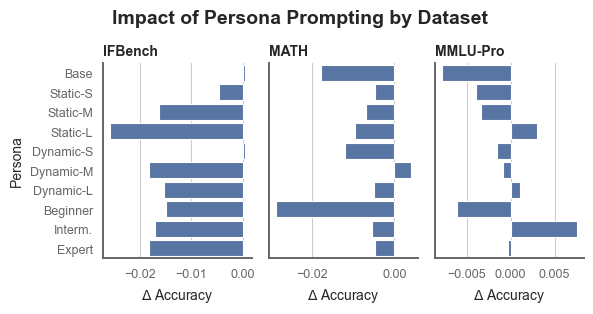

In [16]:
FIG_HEIGHT = 3.0

n_cols = dataset_df["Dataset"].nunique()
aspect = FULL_WIDTH / (FIG_HEIGHT * n_cols)

g = sns.catplot(
    dataset_df, col="Dataset", y="Persona", kind="bar", x="gain", orient="h", sharex=False,
    height=FIG_HEIGHT, aspect=aspect
)

g.figure.suptitle("Impact of Persona Prompting by Dataset")
g.set_titles("{col_name}")
g.set_axis_labels(r"$\Delta$ Accuracy", "Persona")

g.figure.subplots_adjust(
    left=0.16,
    right=0.99,
    top=0.80,
    bottom=0.15,
    wspace=0.12,
)

g.figure.set_size_inches(FULL_WIDTH, FIG_HEIGHT)
g.figure.savefig(plot_path / "1_1_per_dataset.pdf")

- if we split up the comparison dataset-wise, the outcome changes a bit: it is dataset-dependent
- one some datasets, the impact is more positive: e.g. mmlu-pro and MATH
- on some it seems worse: e.g. ifbench
- there is also some variability in the performance impact per-dataset, e.g. on alpaca, dynami ones have a very large impact, on mmlu-pro not so much

In [134]:
winrate_df["Positive"] = winrate_df["Score"] == 2
winrate_df["Neutral"] = winrate_df["Score"] == 1
winrate_df["Negative"] = winrate_df["Score"] == 0

winrate_df = winrate_df[winrate_df["Persona"].isin(_PERSONA_ORDERING)]

winrate_df = winrate_df.groupby(["Dataset", "Persona"], as_index=False).sum(numeric_only=True)
winrate_df["Persona"] = pd.Categorical(
    winrate_df["Persona"],
    categories=_PERSONA_ORDERING,
    ordered=True,
)

winrate_df = winrate_df.sort_values(["Dataset", "Persona"])
winrate_df = winrate_df.set_index("Persona")

In [142]:
def create_winrate_plot(
    data_df: pd.DataFrame,
    dataset_id: str = "FLORES+",
    file_name: str = "flores"
):
    """Create win rate plots.

    Args:
        data_df (pd.DataFrame): Base dataframe.
        dataset_id (str): Dataset identifier.
        file_name (str): File name.
    """
    sub_dataset_df = data_df[data_df["Dataset"] == dataset_id]
    sub_dataset_df = sub_dataset_df[["Positive", "Neutral", "Negative"]]
    sub_dataset_df = sub_dataset_df.div(sub_dataset_df.sum(axis=1), axis=0) * 100

    winrate_fig, winrate_ax = plt.subplots(figsize=(MEDIUM_WIDTH, 3.0))

    winrate_ax = sub_dataset_df.plot(
        kind="bar", stacked=True, ax=winrate_ax,
        color=[colors[col] for col in sub_dataset_df.columns],
        legend=False, width=0.8
    )

    for container in winrate_ax.containers:
        labels = [
            f"{bar.get_height():.0f}%" if bar.get_height() > 6 else ""
            for bar in container
        ]

        winrate_ax.bar_label(
            container,
            labels=labels,
            label_type="center",
            fontsize=8,
            color="white",
        )

    winrate_fig.suptitle(f"Win Rates for {dataset_id}")

    winrate_ax.xaxis.grid(False)
    winrate_ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
    winrate_ax.set_ylabel("Percentage")

    winrate_ax.tick_params(axis="x", rotation=45)
    for winrate_label in winrate_ax.get_xticklabels():
        winrate_label.set_ha("right")

    winrate_fig.subplots_adjust(
        left=0.14,
        right=0.98,
        top=0.90,
        bottom=0.28,
        wspace=0.20,
    )

    winrate_fig.savefig(plot_path / f"1_1_{file_name}.pdf")

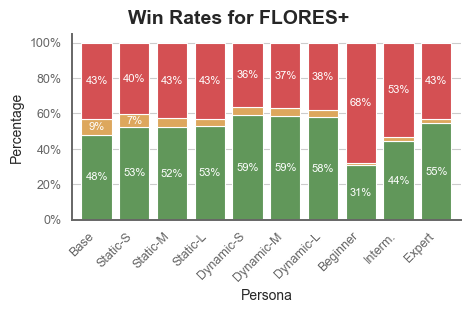

In [143]:
create_winrate_plot(winrate_df)

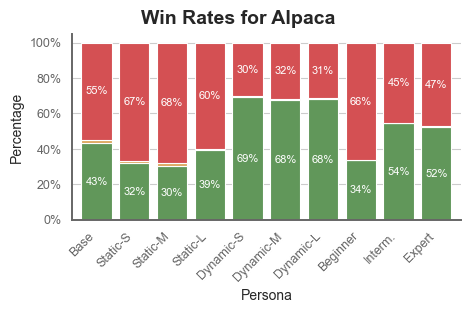

In [144]:
create_winrate_plot(winrate_df, "Alpaca", "alpaca")

In [23]:
dataset_results = tests_baseline_df[tests_baseline_df["category"].isna()]
print_sig(dataset_results, "dataset")

 === MATH ===
    === MATH
    Persona beginner_teacher     p-val 0.002 coef -0.160
 === alpaca ===
    === alpaca
    Persona beginner_teacher     p-val 0.000 coef -0.466
    Persona dynamic_long         p-val 0.000 coef 1.022
    Persona dynamic_medium       p-val 0.000 coef 0.995
    Persona dynamic_short        p-val 0.000 coef 1.077
    Persona expert_teacher       p-val 0.000 coef 0.340
    Persona intermediate_teacher p-val 0.000 coef 0.419
    Persona static_long          p-val 0.000 coef -0.194
    Persona static_medium        p-val 0.000 coef -0.572
    Persona static_short         p-val 0.000 coef -0.500
 === flores ===
    === flores
    Persona beginner_teacher     p-val 0.000 coef -0.903
    Persona dynamic_long         p-val 0.000 coef 0.317
    Persona dynamic_medium       p-val 0.000 coef 0.358
    Persona dynamic_short        p-val 0.000 coef 0.376
    Persona expert_teacher       p-val 0.000 coef 0.148
    Persona intermediate_teacher p-val 0.000 coef -0.289
    Pers

- some datasets benefit more than others (e.g. mmlu-pro)
- ifbench seems completely agnostic to personas
- flores on the other hand seems very good

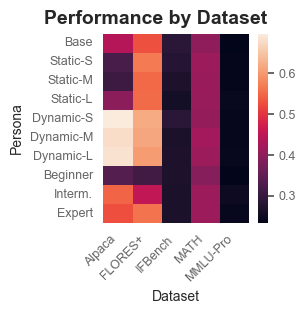

In [131]:
pivot_df = df.groupby(["Dataset", "Persona"], as_index=False)["Score"].mean()
pivot_df = pivot_df.pivot(index="Persona", columns="Dataset", values="Score")
pivot_df = pivot_df.reindex(_order_map.keys())

fig, ax = plt.subplots(figsize=(HALF_WIDTH, 3))

sns.heatmap(data=pivot_df, ax=ax)

fig.suptitle("Performance by Dataset")

fig.subplots_adjust(
    left=0.32,
    right=0.95,
    top=0.90,
    bottom=0.27,
)

ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

fig.savefig(plot_path / "1_0_datasets_heatmap.pdf")

## Performance By Dataset Subcategory

In [25]:
category_df = df.copy()
category_df = category_df.groupby(["Dataset", "model", "category", "Persona"], as_index=False)[["Score"]].mean()

parts = []
for dataset_name, group_df in category_df.groupby(["category", "model"], sort=False):
    if "helpful" in group_df["Persona"].unique():
        ref = group_df.loc[group_df["Persona"] == "helpful", "Score"]

        ref_score = ref.iloc[0]
        group_df["reference_score"] = ref_score
        group_df["gain"] = group_df["Score"] - ref_score
    else:
        group_df["gain"] = group_df["Score"]
    parts.append(group_df)

category_df: pd.DataFrame = pd.concat(parts, ignore_index=True)
category_df = category_df.sort_values("Persona", key=lambda s: s.map(_order_map))
category_df = category_df[category_df["Persona"] != "helpful"]

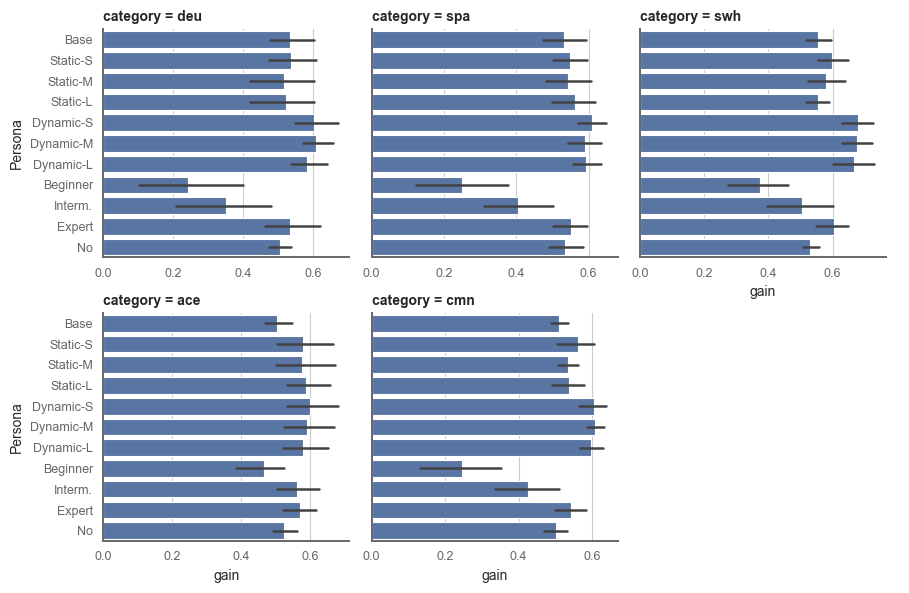

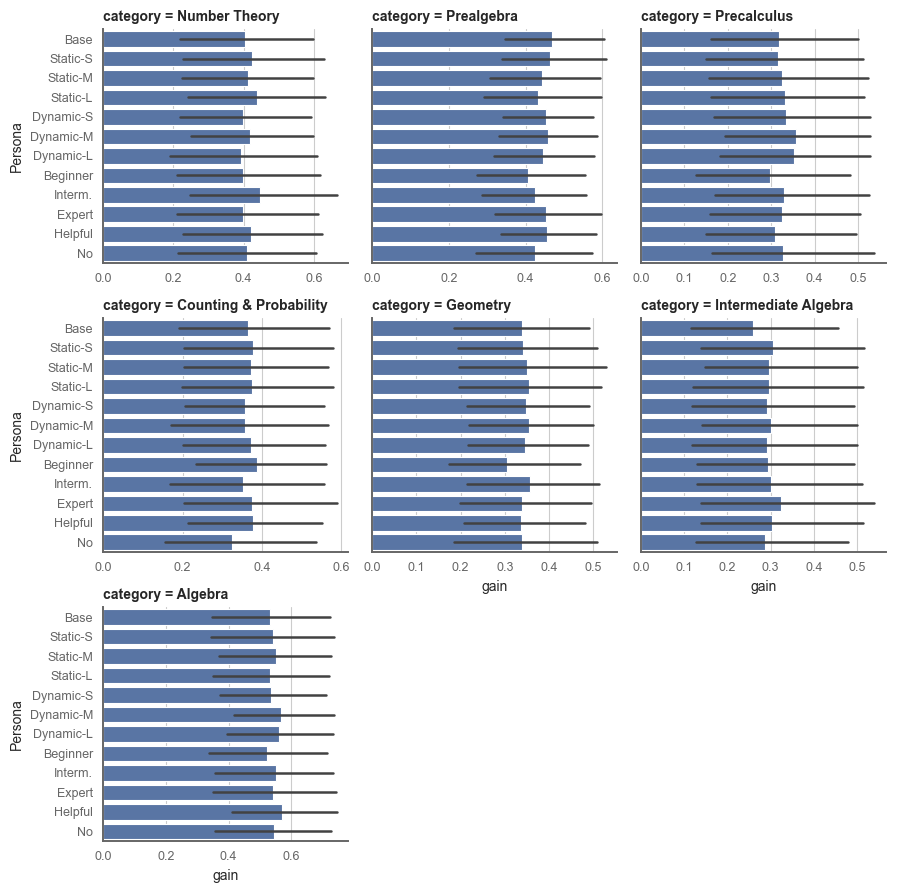

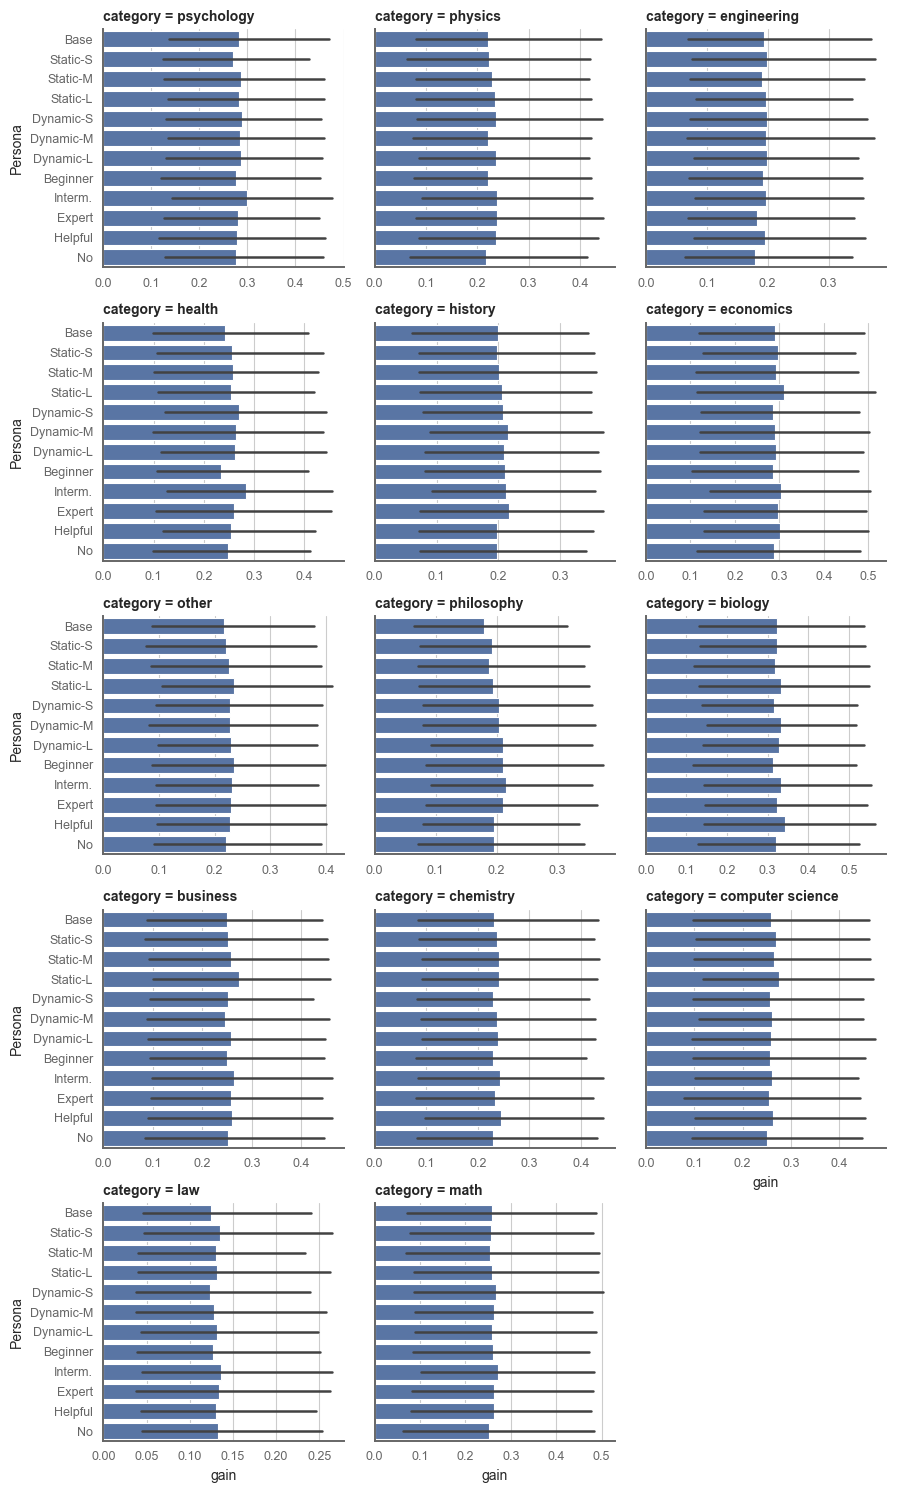

In [26]:
for dataset, sub_df in category_df.groupby("Dataset"):
    sns.catplot(sub_df, col="category", y="Persona", kind="bar", x="gain", orient="h", sharex=False, height=3, col_wrap=3)

- similar to datasets as a whole, the impact of personas also depends on subcategories

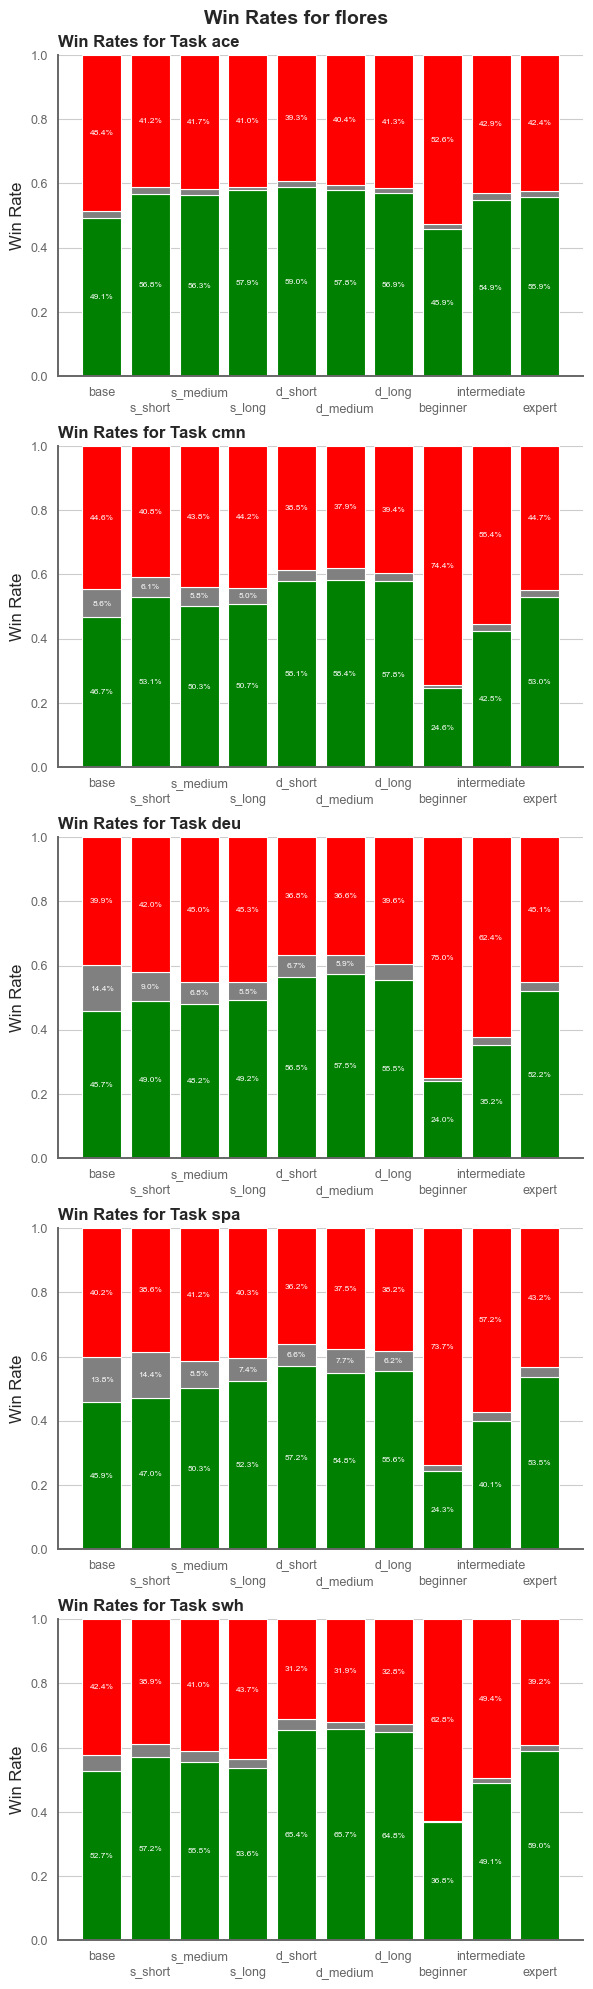

In [27]:
plotting_wrapper.create_stacked_barchart_plots("flores", "iso_639_3")

In [28]:
print_sig(tests_baseline_df, "category")

 === MATH ===
    === Algebra
    Persona base                 p-val 0.038 coef -0.221
    Persona beginner_teacher     p-val 0.008 coef -0.284
    Persona dynamic_short        p-val 0.049 coef -0.210
    Persona static_long          p-val 0.033 coef -0.227
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    Persona base                 p-val 0.013 coef -0.350
    === Number Theory
    === Prealgebra
    Persona beginner_teacher     p-val 0.046 coef -0.241
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    Persona beginner_teacher     p-val 0.034 coef -0.152
    Persona dynamic_long         p-val 0.000 coef 0.302
    Persona dynamic_medium       p-val 0.000 coef 0.343
    Persona dynamic_short        p-val 0.000 coef 0.391
    Persona expert_teacher       p-val 0.000 coef 0.264
    Persona intermediate_teacher p-val 0.001 coef 0.235
    Persona static_long          p-val 0.000 coef 0.334
    Persona static_medium        p-val 0.000 coef 0.2

- outcome also quite sensitive to categorize
- dynamic persona even stronger than before
- teachers follow mostly positive trend
- but partially, results are not significant anymore


# 2. Comparison by length

In [29]:
from evaluate import prepare_length

dfs = []
for mode in ["static", "dynamic", "combined"]:
    mode: Literal["static", "dynamic", "combined"] = mode   # to silence warning
    length_df = prepare_length(length_base_df, mode)
    length_df["Mode"] = mode.capitalize()
    dfs.append(length_df)
length_df: pd.DataFrame = pd.concat(dfs)

length_mapping = {1: "base", 2: "short", 3: "medium", 4: "long"}
length_df["Persona Length"] = length_df["length"].map(length_mapping)
length_df["Persona Length"] = pd.Categorical(length_df["Persona Length"], categories=length_mapping.values(), ordered=True)
length_df = length_df.rename(columns={"score": "Score", "dataset": "Dataset"})
length_df["Dataset"] = length_df["Dataset"].replace(dataset_names)

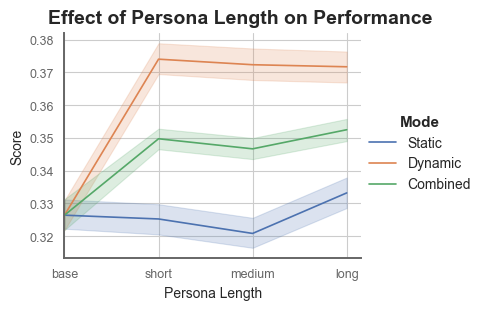

In [50]:
n_cols = 1
aspect = MEDIUM_WIDTH / (3.0 * n_cols)

facet_kw = {"sharey": "row"}
g = sns.relplot(
    length_df, x="Persona Length", y="Score", hue="Mode", kind="line",
    height=3.0, aspect=aspect, facet_kws=facet_kw
)

g.figure.suptitle("Effect of Persona Length on Performance")
g.figure.set_size_inches(MEDIUM_WIDTH, 3.0)

g.figure.subplots_adjust(
    left=0.12,
    right=0.76,
    top=0.90,
    bottom=0.15,
    wspace=0.28,
)

sns.move_legend(
    g,
    loc="center left",
    bbox_to_anchor=(0.75, 0.50),
    bbox_transform=g.figure.transFigure,
    frameon=False,
)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlim(left=0)

main_legend = g.legend
if main_legend is not None:
    main_legend.get_title().set_fontweight("bold")

g.figure.savefig(plot_path / "2_0_datasets.pdf")

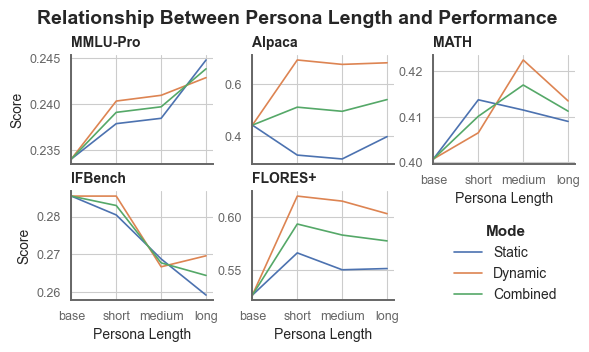

In [41]:
n_cols = 3
aspect = FULL_WIDTH / (3.5 * n_cols)

facet_kw = {
    "sharey": False,
    "legend_out": False,
}
g = sns.relplot(
    length_df, x="Persona Length", y="Score", col="Dataset", hue="Mode", kind="line",
    facet_kws=facet_kw, err_style=None, height=3.5, aspect=aspect, col_wrap=n_cols
)

g.figure.suptitle("Relationship Between Persona Length and Performance")
g.set_titles("{col_name}")

g.figure.set_size_inches(FULL_WIDTH, 3.5)

g.figure.subplots_adjust(
    left=0.11,
    right=0.98,
    top=0.85,
    bottom=0.15,
    wspace=0.28,
    hspace=0.25
)

sns.move_legend(
    g,
    loc="upper left",
    bbox_to_anchor=(0.75, 0.40),
    bbox_transform=g.figure.transFigure,
    frameon=False,
)

main_legend = g.legend
if main_legend is not None:
    main_legend.get_title().set_fontweight("bold")

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlim(left=0)

g.figure.savefig(plot_path / "2_1_per_dataset.pdf")

In [43]:
dataset_len_results = tests_length_df[tests_length_df["category"].isna()]
print_sig(dataset_len_results, "dataset")

 === MATH ===
    === MATH
 === alpaca ===
    === alpaca
    Persona length               p-val 0.000 coef -0.069
static
    Persona length               p-val 0.000 coef 0.312
dynamic
    Persona length               p-val 0.000 coef 0.100
combined
 === flores ===
    === flores
    Persona length               p-val 0.004 coef 0.029
static
    Persona length               p-val 0.000 coef 0.097
dynamic
    Persona length               p-val 0.000 coef 0.043
combined
 === ifbench ===
    === ifbench
    Persona length               p-val 0.019 coef -0.051
static
    Persona length               p-val 0.010 coef -0.046
combined
 === mmlu-pro ===
    === mmlu-pro
    Persona length               p-val 0.002 coef 0.026
static
    Persona length               p-val 0.011 coef 0.021
dynamic
    Persona length               p-val 0.001 coef 0.022
combined


- ifbench showed mostly negative trends before, so it is expected that the length will also have a negative impact
- MATH and mmlu-pro seem most intuitive, though mmlu-pro does not have a statistically significant impact
- very little strictly monotonic cases

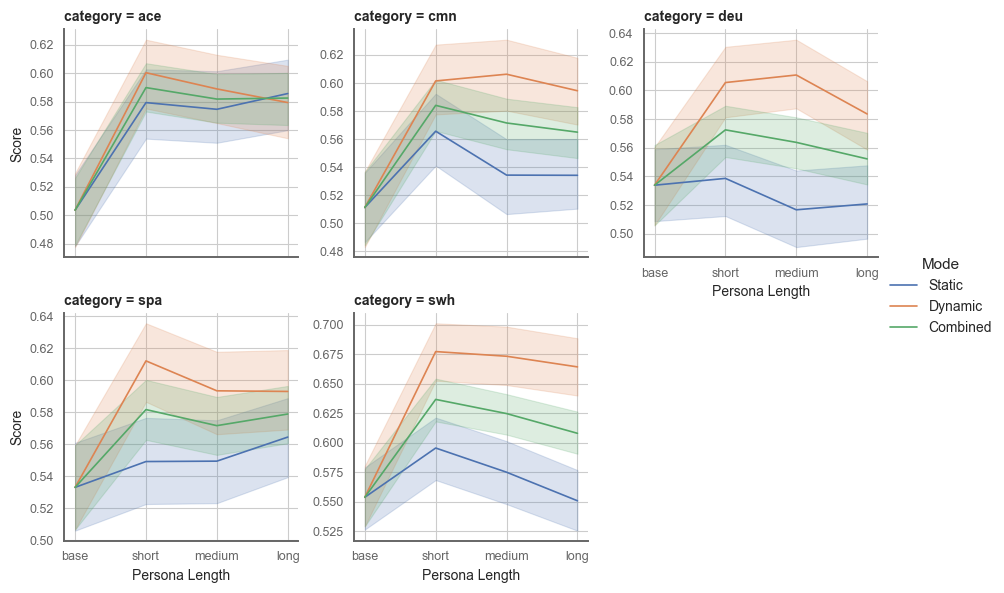

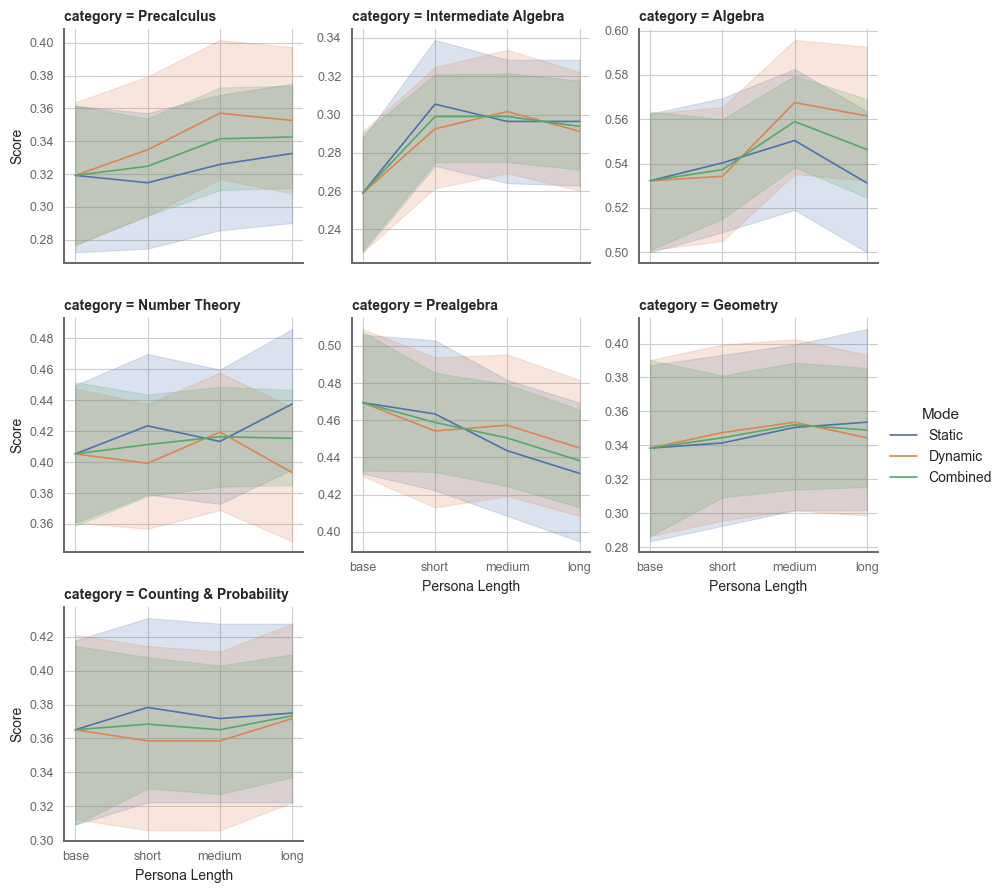

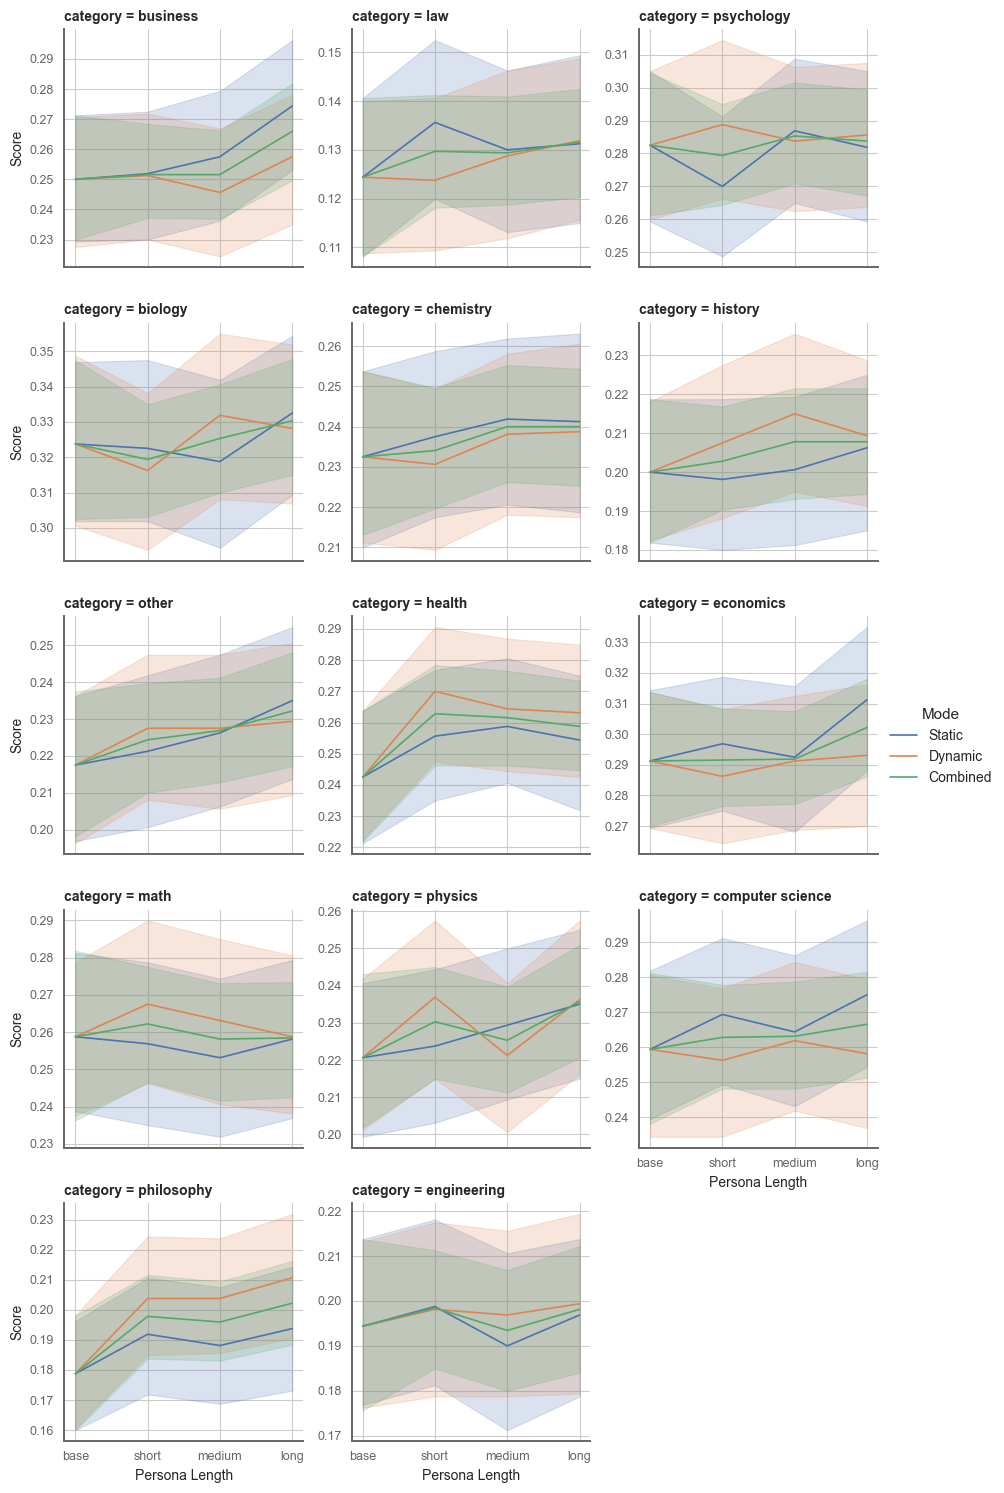

In [45]:
facet_kw = {"sharey": False}
d_cat_df = length_df.dropna()
for dataset, group_df in d_cat_df.groupby("Dataset"):
    sns.relplot(group_df, x="Persona Length", y="Score", hue="Mode", col="category", kind="line", facet_kws=facet_kw, height=3, col_wrap=3)

In [46]:
print_sig(tests_length_df, "category")

 === MATH ===
    === Algebra
    Persona length               p-val 0.046 coef 0.066
dynamic
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    === Number Theory
    === Prealgebra
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    Persona length               p-val 0.000 coef 0.101
static
    Persona length               p-val 0.000 coef 0.088
dynamic
    Persona length               p-val 0.000 coef 0.070
combined
    === cmn
    Persona length               p-val 0.000 coef 0.108
dynamic
    Persona length               p-val 0.020 coef 0.043
combined
    === deu
    Persona length               p-val 0.001 coef 0.074
dynamic
    === spa
    Persona length               p-val 0.045 coef 0.044
static
    Persona length               p-val 0.001 coef 0.071
dynamic
    Persona length               p-val 0.010 coef 0.046
combined
    === swh
    Persona length               p-val 0.000 coef 0.152
dynamic
    Persona length               p-

- only clear trend observable is that dynamic personas seem very strong on flores+
- also: it seems like the medium length persona is always quite bad, while longer and shorter ones are better

# 3. Comparison by expertise

In [60]:
from evaluate import prepare_teacher

teacher_df = prepare_teacher(length_base_df)
teacher_mapping = {0: "beginner", 1: "intermediate", 2: "expert"}
teacher_df["Audience Level"] = teacher_df["level"].map(teacher_mapping)
teacher_df["Audience Level"] = pd.Categorical(teacher_df["Audience Level"], categories=["beginner", "intermediate", "expert"], ordered=True)

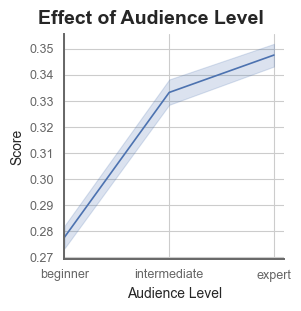

In [151]:
n_cols = 1
aspect = HALF_WIDTH / (3.0 * n_cols)

g = sns.relplot(
    teacher_df, x="Audience Level", y="Score", kind="line", height=3, aspect=aspect
)

g.figure.suptitle("Effect of Audience Level")
g.figure.set_size_inches(HALF_WIDTH, 3.0)

g.figure.subplots_adjust(
    left=0.20,
    right=0.96,
    top=0.90,
    bottom=0.15,
    wspace=0.28,
)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlim(left=0)

g.figure.savefig(plot_path / "3_0_datasets.pdf")

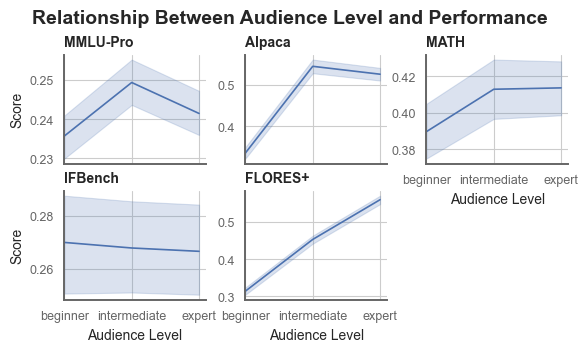

In [62]:
n_cols = 3
aspect = FULL_WIDTH / (3.5 * n_cols)


facet_kw = {
    "sharey": False,
    "legend_out": False,
}
g = sns.relplot(
    teacher_df, x="Audience Level", y="Score", col="Dataset",
    kind="line", col_wrap=3, facet_kws=facet_kw, height=3
)

g.figure.suptitle("Relationship Between Audience Level and Performance")
g.set_titles("{col_name}")

g.figure.set_size_inches(FULL_WIDTH, 3.5)

g.figure.subplots_adjust(
    left=0.11,
    right=0.98,
    top=0.85,
    bottom=0.15,
    wspace=0.28,
    hspace=0.25
)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlim(left=0)

g.figure.savefig(plot_path / "3_1_per_dataset.pdf")

In [64]:
dataset_teacher_results = tests_teacher_df[tests_teacher_df["category"].isna()]
print_sig(dataset_teacher_results, "dataset")

 === MATH ===
    === MATH
    Persona level                p-val 0.011 coef 0.068
 === alpaca ===
    === alpaca
    Persona level                p-val 0.000 coef 0.415
 === flores ===
    === flores
    Persona level                p-val 0.000 coef 0.518
 === ifbench ===
    === ifbench
 === mmlu-pro ===
    === mmlu-pro


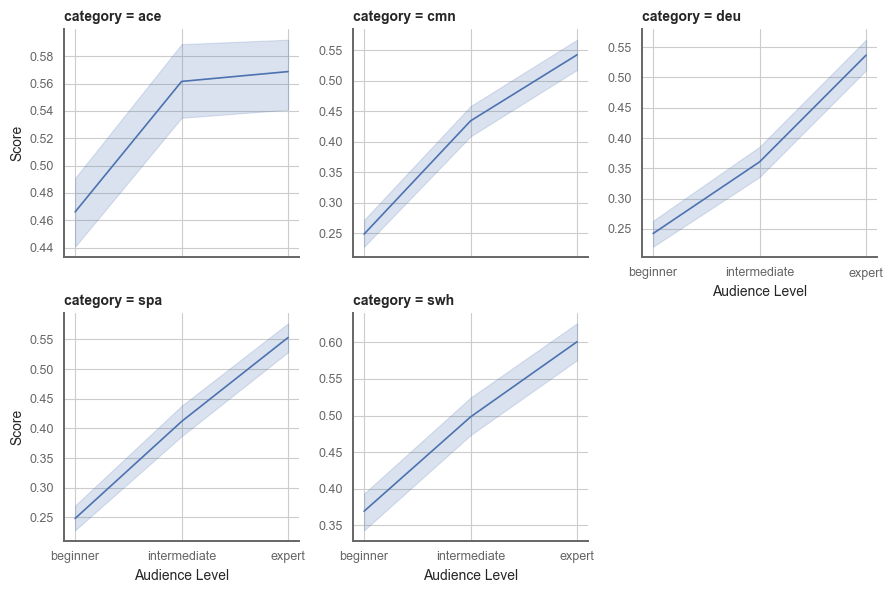

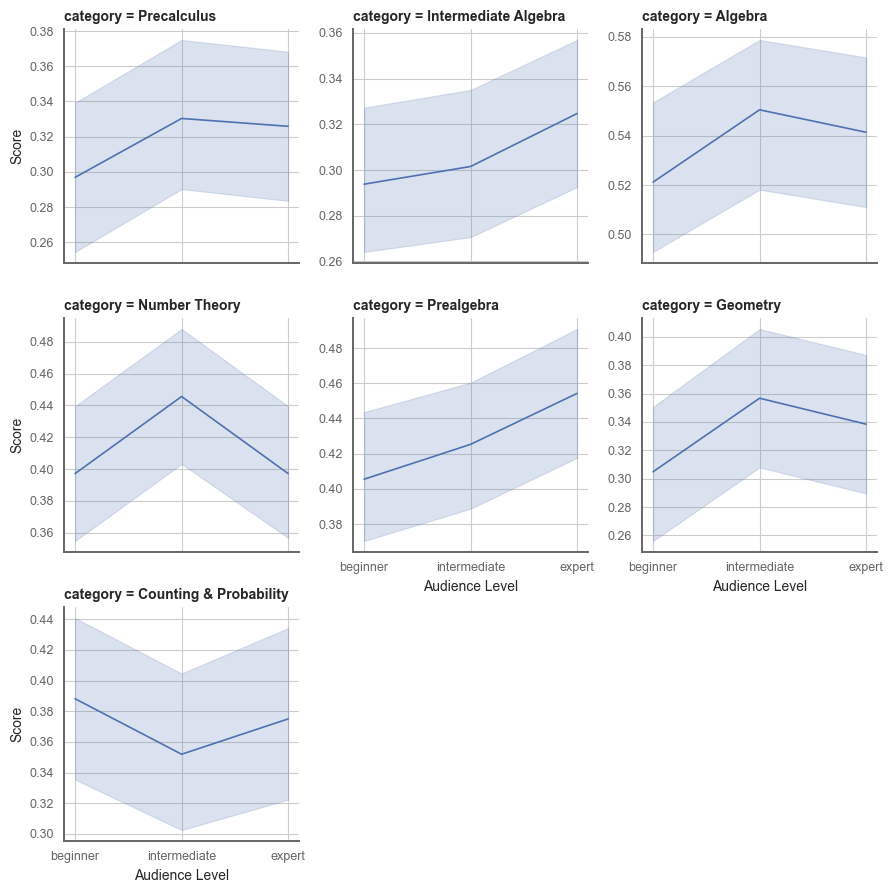

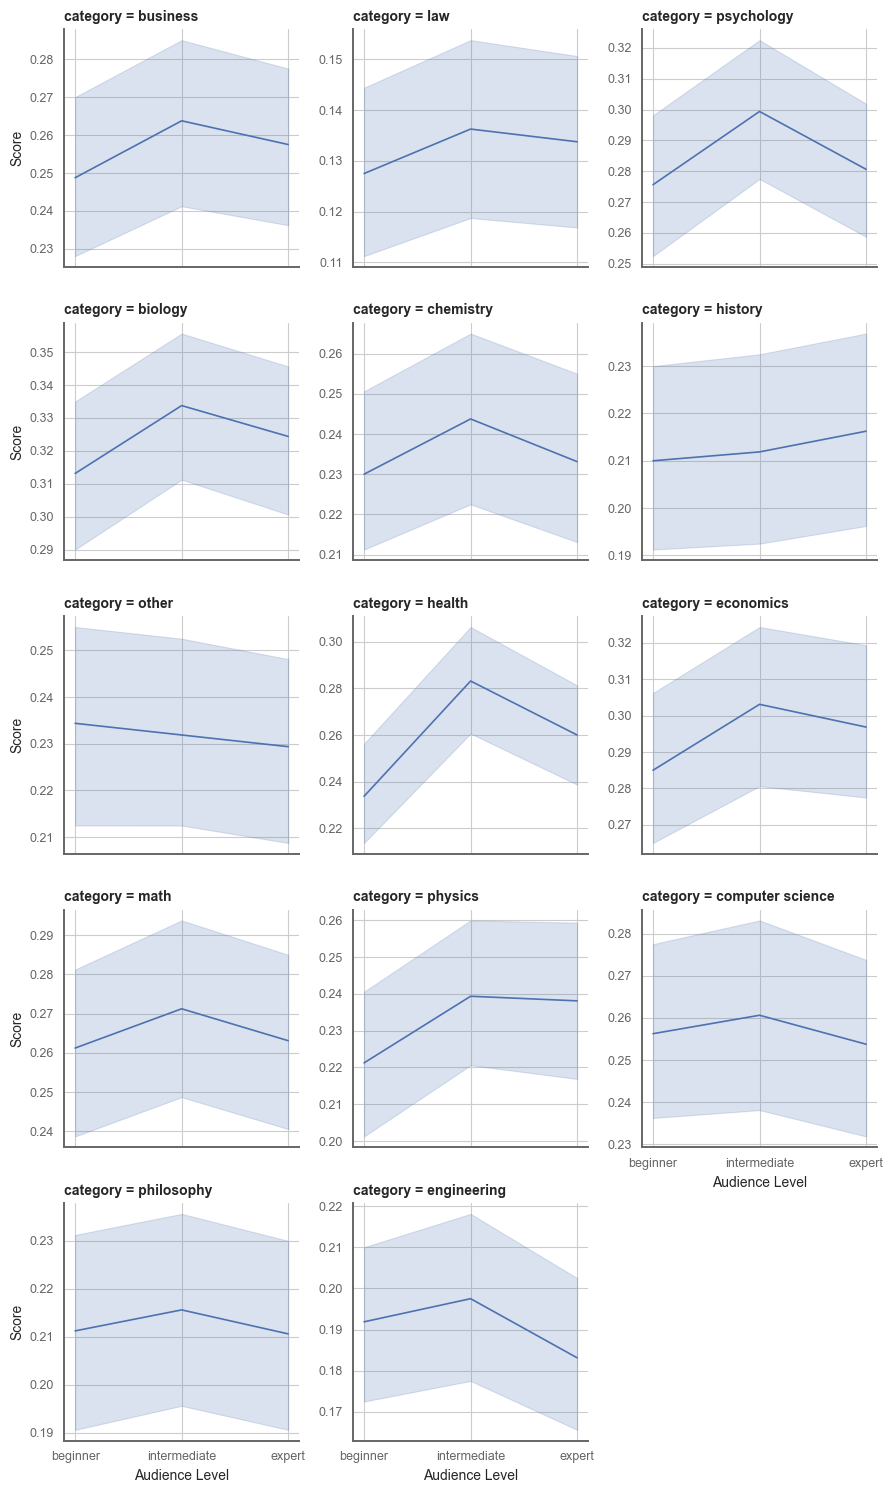

In [66]:
facet_kw = {"sharey": False}
t_cat_df = teacher_df.dropna()
for dataset, group_df in t_cat_df.groupby("Dataset"):
    sns.relplot(group_df, x="Audience Level", y="Score", col="category", kind="line", facet_kws=facet_kw, height=3, col_wrap=3)

In [67]:
print_sig(tests_teacher_df, "category")

 === MATH ===
    === Algebra
    === Counting & Probability
    === Geometry
    === Intermediate Algebra
    === Number Theory
    === Prealgebra
    === Precalculus
 === alpaca ===
 === flores ===
    === ace
    Persona level                p-val 0.000 coef 0.207
    === cmn
    Persona level                p-val 0.000 coef 0.649
    === deu
    Persona level                p-val 0.000 coef 0.728
    === spa
    Persona level                p-val 0.000 coef 0.674
    === swh
    Persona level                p-val 0.000 coef 0.486
 === ifbench ===
 === mmlu-pro ===
    === biology
    === business
    === chemistry
    === computer science
    === economics
    === engineering
    === health
    Persona level                p-val 0.044 coef 0.097
    === history
    === law
    === math
    === other
    === philosophy
    === physics
    === psychology


# 4. Static vs. Dynamic

In [70]:
from evaluate import prepare_static_vs_dynamic

dynamic_df = prepare_static_vs_dynamic(length_base_df)
dynamic_df.reset_index(inplace=True)
dynamic_df = dynamic_df.rename(columns={"is_dynamic": "Persona Type"})
dynamic_df["Persona Type"] = dynamic_df["Persona Type"].replace({0: "Static", 1: "Dynamic"})

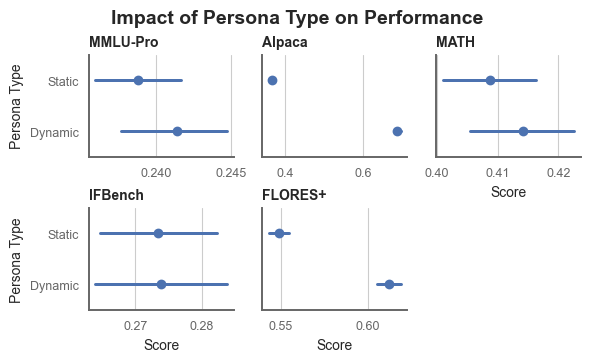

In [85]:
FIG_HEIGHT = 3.5

n_cols = 3
aspect = FULL_WIDTH / (FIG_HEIGHT * n_cols)

g = sns.catplot(
    dynamic_df, col="Dataset", x="Score", y="Persona Type", kind="point", orient="h", col_wrap=n_cols, sharex=False, height=FIG_HEIGHT, linestyle="none"
)

g.figure.suptitle("Impact of Persona Type on Performance")

g.set_titles("{col_name}")

g.figure.subplots_adjust(
    left=0.14,
    right=0.99,
    top=0.85,
    bottom=0.12,
    wspace=0.20,
    hspace=0.50
)

g.figure.set_size_inches(FULL_WIDTH, FIG_HEIGHT)
g.figure.savefig(plot_path / "4_0_datasets.pdf")

In [ ]:
dataset_dynamic_results = tests_dynamic_df[tests_dynamic_df["category"].isna()]
print_sig(dataset_dynamic_results, "Dataset")

In [ ]:
for dataset, dynamic_group_df in dynamic_df.groupby("Dataset"):
    sns.catplot(dynamic_df, col="category", y="is_dynamic", x="Score", kind="point", orient="h", col_wrap=3, sharex=False, height=2, linestyle="none")

In [ ]:
print_sig(tests_dynamic_df, "category")